In [1]:
# Install CLIP Dependencies
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git
!pip install clip-anytorch autokeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-djnc9iut
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-djnc9iut
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=16b11b58b4f9d2af938ca3f5897517e7cf425ec0959459729e913577ef8db701
  Stored in directory: /tmp/pip-ephem-wheel-cache-0jxbm2fo/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 16.2 MB/s eta 0:00:00


In [2]:
import pickle
from google.colab import drive

# Mount Google Drive first
drive.mount('/content/drive')

# Reload the updated pkl files
with open('/content/drive/MyDrive/dataset/taste_descriptions.pkl', 'rb') as f:
    taste_descriptions = pickle.load(f)

with open('/content/drive/MyDrive/dataset/emotion_descriptions.pkl', 'rb') as f:
    emotion_descriptions = pickle.load(f)

# Verify number of tokens
def count_clip_tokens(text: str) -> int:
    """Count exact CLIP tokens for a given string."""
    tokens = clip.tokenize(text, truncate=True)
    # subtract 2 for the start and end tokens
    return tokens[0].nonzero().shape[0] - 2

Mounted at /content/drive


# Import Libraries and Setup

In [3]:
import torch
import clip
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import skimage
import IPython.display

from collections import OrderedDict
import torch

In [4]:
# Load CLIP model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, preprocess = clip.load('ViT-B/32', device=device)

print(f'CLIP model loaded on {device}')

100%|████████████████████████████████████████| 354M/354M [00:02<00:00, 169MiB/s]


CLIP model loaded on cuda


In [5]:
print("TASTE DESCRIPTIONS")
for taste, desc in taste_descriptions.items():
    token_count = count_clip_tokens(desc)
    print(f"[{taste}] {token_count}/77 tokens {'TOO LONG' if token_count >= 77 else 'OK'}")

print("EMOTION DESCRIPTIONS")
for emotion, desc in emotion_descriptions.items():
    token_count = count_clip_tokens(desc)
    print(f"[{emotion}] {token_count}/77 tokens {'TOO LONG' if token_count >= 77 else 'OK'}\n{desc}\n")

TASTE DESCRIPTIONS
[sweet] 75/77 tokens OK
[sour] 54/77 tokens OK
[salty] 73/77 tokens OK
[bitter] 75/77 tokens OK
[umami] 50/77 tokens OK
EMOTION DESCRIPTIONS
[happy] 44/77 tokens OK
A book cover that features Low to Medium angularity, High roundness, Medium symmetry, Medium elements, Yellow, Orange hues, High brightness, High saturation, Smooth/ Soft textures, Medium (Playful) complexity.

[pleasure] 49/77 tokens OK
A book cover that features Low angularity, Very High roundness, High (D8/Radial) symmetry, Low to Medium elements, Pink, Warm Red hues, High brightness, Medium saturation, Smooth/Creamy textures, Low complexity.

[asthonished] 57/77 tokens OK
A book cover that features High (Spiky/Starbursts) angularity, Low roundness, Low or Radial symmetry, High elements, Neon Green, Bright Yellow, High Contrast hues, High brightness, High saturation, Sharp/Rough textures, High (Unexpected elements) complexity.

[relaxed] 46/77 tokens OK
A book cover that features Low angularity, High r

# Helper Functions

In [6]:
def get_prototypes(prompt_sets, model, device):
    """Generate CLIP text embeddings for emotion descriptions"""
    labels = list(prompt_sets.keys())
    all_prompts = [prompt_sets[label] for label in labels]

    # Tokenize and encode
    tokens = clip.tokenize(all_prompts, truncate=True).to(device)
    with torch.no_grad():
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return labels, text_features

# Visualisation Function

In [7]:
def plot_top5_grid(image_paths, labels, prototypes, features, k=5):
    """
    Plots a grid where:
    - Rows = Emotions
    - Columns = The Top k images for that emotion
    - Enforces uniqueness (no image appears twice)
    """

    # Calculate similarity matrix (Emotions x All Images)
    full_sims = (prototypes.cpu() @ features.cpu().T).numpy()

    # Storage for our results
    results = {}
    used_indices = set()

    for i, label in enumerate(labels):
        scores = full_sims[i]
        sorted_indices = scores.argsort()[::-1] # High to low

        top_matches = []
        for idx in sorted_indices:
            if idx not in used_indices:
                score = scores[idx]
                top_matches.append((idx, score))
                used_indices.add(idx)

                if len(top_matches) == k:
                    break

        results[label] = top_matches

    # Plotting the grid
    n_rows = len(labels)
    n_cols = k

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.5 * n_rows))

    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    for row_idx, label in enumerate(labels):
        matches = results[label]

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]

            if col_idx < len(matches):
                img_idx, score = matches[col_idx]
                path = image_paths[img_idx]

                try:
                    img = Image.open(path).convert("RGB")
                    # Resize to keep file size down and aspect ratio consistent
                    img.thumbnail((200, 300))
                    ax.imshow(img)
                except:
                    ax.text(0.5, 0.5, "Error", ha='center')

                ax.set_title(f"$S_c$ = {score:.3f}", fontsize=16, fontweight='bold')

            ax.axis("off")

            if col_idx == 0:
                ax.text(-0.2, 0.5, label.upper(),
                        transform=ax.transAxes,
                        rotation=90, va='center', ha='right',
                        fontsize=14, fontweight='bold')

    plt.show()

# Download and Load Dataset

In [8]:
# Download dataset
dataset_path = kagglehub.dataset_download("mexwell/book-cover-dataset")

100%|██████████| 675M/675M [00:05<00:00, 122MB/s]

Extracting files...


In [9]:
# Load and encode images
def load_and_encode_from_folder(folder_path, limit=None, batch_size=750):
    """Recursively finds images and encodes them in batches"""
    image_paths = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
        #         if limit and len(image_paths) >= limit:
        #             break
        # if limit and len(image_paths) >= limit:
        #     break

    print(f"Found {len(image_paths)} images")

    # Encode in batches
    all_features = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            try:
                img = preprocess(Image.open(path)).unsqueeze(0).to(device)
                batch_images.append(img)
            except Exception as e:
                print(f"Error loading {path}: {e}")

        if batch_images:
            batch_tensor = torch.cat(batch_images)
            with torch.no_grad():
                features = model.encode_image(batch_tensor)
                features = features / features.norm(dim=-1, keepdim=True)
                all_features.append(features)

        print(f"Processed {min(i+batch_size, len(image_paths))}/{len(image_paths)} images")

    all_features = torch.cat(all_features)
    return image_paths, all_features


# Load images (adjust limit as needed)
valid_image_paths, image_features = load_and_encode_from_folder(dataset_path)
print(f"Loaded and encoded {len(valid_image_paths)} images")
print(f"Image features shape: {image_features.shape}")

Found 57000 images
Processed 750/57000 images
Processed 1500/57000 images
Processed 2250/57000 images
Processed 3000/57000 images
Processed 3750/57000 images
Processed 4500/57000 images
Processed 5250/57000 images
Processed 6000/57000 images
Processed 6750/57000 images
Processed 7500/57000 images
Processed 8250/57000 images
Processed 9000/57000 images
Processed 9750/57000 images
Processed 10500/57000 images
Processed 11250/57000 images
Processed 12000/57000 images
Processed 12750/57000 images
Processed 13500/57000 images
Processed 14250/57000 images
Processed 15000/57000 images
Processed 15750/57000 images
Processed 16500/57000 images
Processed 17250/57000 images
Processed 18000/57000 images
Processed 18750/57000 images
Processed 19500/57000 images
Processed 20250/57000 images
Processed 21000/57000 images
Processed 21750/57000 images
Processed 22500/57000 images
Processed 23250/57000 images
Processed 24000/57000 images
Processed 24750/57000 images
Processed 25500/57000 images
Processed

# Dataset cleansing

In [10]:
import urllib.request
import zipfile
import tensorflow as tf

def load_safety_model(clip_model_name="ViT-B/32"):
    """
    Loads a CLIP-embedding-based NSFW classifier
    """
    cache_folder = "./NSFW-cache"
    os.makedirs(cache_folder, exist_ok=True)

    if clip_model_name == "ViT-L/14":
        model_dir = os.path.join(cache_folder, "clip_autokeras_binary_nsfw")
        url_model = "https://raw.githubusercontent.com/LAION-AI/CLIP-based-NSFW-Detector/main/clip_autokeras_binary_nsfw.zip"
        expected_dim = 768
    elif clip_model_name == "ViT-B/32":
        model_dir = os.path.join(cache_folder, "clip_autokeras_nsfw_b32")
        url_model = "https://raw.githubusercontent.com/LAION-AI/CLIP-based-NSFW-Detector/main/clip_autokeras_nsfw_b32.zip"
        expected_dim = 512
    else:
        raise ValueError(f"Unsupported clip_model_name: {clip_model_name}")

    # Download and extract if the folder doesn't exist
    if not os.path.exists(model_dir):
        print(f"Downloading NSFW safety model from {url_model}...")
        zip_path = os.path.join(cache_folder, "model.zip")
        urllib.request.urlretrieve(url_model, zip_path)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(cache_folder)

        os.remove(zip_path)
        print(f"✓ Model downloaded and extracted to {model_dir}")

    # Load the TensorFlow saved model
    safety_model = tf.saved_model.load(model_dir)
    print(f"✓ Safety model loaded (expected dim: {expected_dim})")

    return safety_model, expected_dim


# Load the safety model
safety_model, safety_expected_dim = load_safety_model("ViT-B/32")

✓ Model downloaded and extracted to ./NSFW-cache/clip_autokeras_nsfw_b32
✓ Safety model loaded (expected dim: 512)


In [11]:
def filter_nsfw(image_paths, image_features, safety_model, expected_dim, threshold=0.5):
    """
    Filter images using TensorFlow NSFW safety model

    Parameters:
    -----------
    image_paths : list
        Paths to images
    image_features : torch.Tensor
        CLIP embeddings for images
    safety_model : TensorFlow model
        Loaded NSFW detection model
    expected_dim : int
        Expected embedding dimension (512 for ViT-B/32)
    threshold : float
        NSFW probability threshold (lower = stricter)

    Returns:
    --------
    filtered_paths : list
        Paths to safe images
    filtered_features : torch.Tensor
        Features for safe images
    nsfw_scores : np.array
        NSFW scores for each image
    """
    if image_features is None:
        return image_paths, image_features, None

    # Convert to TensorFlow format
    emb_np = image_features.detach().cpu().numpy().astype(np.float64)
    emb_tf = tf.convert_to_tensor(emb_np, dtype=tf.float64)

    if emb_tf.shape[1] != expected_dim:
        raise ValueError(f"Embedding dim mismatch: {emb_tf.shape[1]} vs {expected_dim}")

    # Run inference
    serving_fn = safety_model.signatures['serving_default']
    raw_preds = serving_fn(emb_tf)

    # Extract results
    first_key = list(raw_preds.keys())[0]
    preds = raw_preds[first_key].numpy().flatten()

    # Filter based on threshold
    mask_np = preds < threshold
    filtered_paths = [p for p, keep in zip(image_paths, mask_np) if keep]
    filtered_features = image_features[mask_np] if mask_np.any() else None

    num_removed = (~mask_np).sum()
    print(f"✓ Safety model filter: Removed {num_removed}/{len(image_paths)} images")
    print(f"  Threshold: {threshold:.2f}")
    print(f"  Remaining: {len(filtered_paths)} images")

    return filtered_paths, filtered_features, preds

In [12]:
print("APPLYING NSFW FILTER")

# Store original count
original_count = len(valid_image_paths)

print("TensorFlow NSFW Safety Model")
SAFETY_THRESHOLD = 0.1  # Lower = stricter (typical range: 0.1-0.5)
image_paths, image_features, nsfw_scores = filter_nsfw(
    valid_image_paths,
    image_features,
    safety_model,
    safety_expected_dim,
    threshold=SAFETY_THRESHOLD
)

APPLYING NSFW FILTER
TensorFlow NSFW Safety Model
✓ Safety model filter: Removed 716/57000 images
  Threshold: 0.10
  Remaining: 56284 images


# Generate Prototypes

In [13]:
emotion_labels, emotion_prototypes = get_prototypes(emotion_descriptions, model, device)
taste_labels, taste_prototypes = get_prototypes(taste_descriptions, model, device)

# Top Books for Each Emotion and Taste

In [14]:
plot_top5_grid(image_paths, emotion_labels, emotion_prototypes, image_features, k=5)

Output hidden; open in https://colab.research.google.com to view.

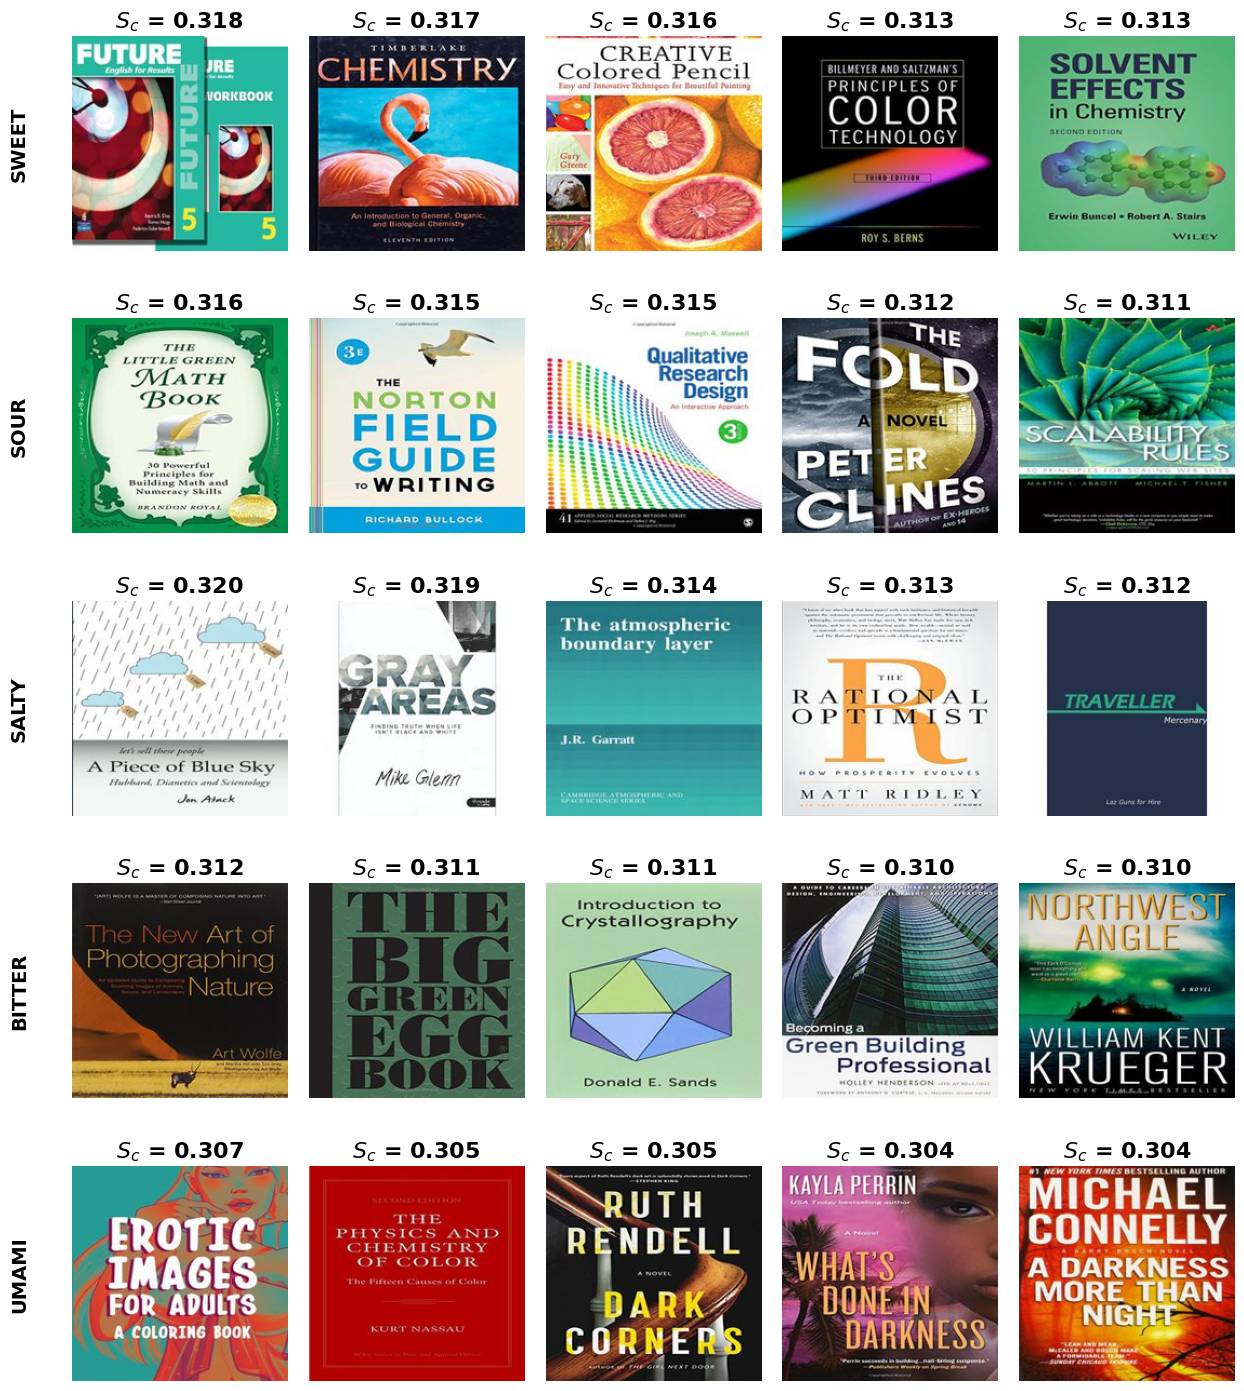

In [15]:
plot_top5_grid(image_paths, taste_labels, taste_prototypes, image_features, k=5)

In [16]:
import shutil
import os
from PIL import Image

def save_top5_images(image_paths, labels, prototypes, features, k=5, output_dir="top5_exports", target_width=200):
    os.makedirs(output_dir, exist_ok=True)

    full_sims = (prototypes.cpu() @ features.cpu().T).numpy()

    used_indices = set()

    for i, label in enumerate(labels):
        scores = full_sims[i]
        sorted_indices = scores.argsort()[::-1]

        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        count = 0
        for idx in sorted_indices:
            if idx not in used_indices:
                score = scores[idx]
                src_path = image_paths[idx]
                ext = os.path.splitext(src_path)[-1].lower() or ".jpg"

                dest_filename = f"{label}_rank{count+1}{ext}"
                dest_path = os.path.join(label_dir, dest_filename)

                # Resizing to target width for user study
                img = Image.open(src_path).convert("RGB")
                aspect_ratio = img.height / img.width
                new_height = int(target_width * aspect_ratio)
                img = img.resize((target_width, new_height), Image.LANCZOS)
                img.save(dest_path)

                used_indices.add(idx)
                count += 1

                if count == k:
                    break

In [17]:
# save_top5_images(image_paths, emotion_labels, emotion_prototypes, image_features, k=5, output_dir="nlp_top5_emotions", target_width=400)
# import shutil
# from google.colab import files

# # Zip the entire parent folder
# shutil.make_archive('/content/nlp_top5_emotions', 'zip', '/content/nlp_top5_emotions')

# # Download the zip
# files.download('/content/nlp_top5_emotions.zip')

# Mapping Emotion to Taste

In [18]:
def get_emotion_pool(image_paths, emotion_labels, emotion_prototypes, image_features, k=5):
    """
    Returns a list of (img_idx, path, emotion_label, emotion_score)
    for the top-k unique books per emotion.
    """
    full_sims = (emotion_prototypes.cpu() @ image_features.cpu().T).numpy()

    pool = []           # list of dicts
    used_indices = set()

    for i, emotion in enumerate(emotion_labels):
        scores = full_sims[i]
        sorted_indices = scores.argsort()[::-1]

        count = 0
        for idx in sorted_indices:
            if idx not in used_indices:
                pool.append({
                    "img_idx":       int(idx),
                    "path":          image_paths[idx],
                    "emotion":       emotion,
                    "emotion_score": float(scores[idx]),
                })
                used_indices.add(idx)
                count += 1
                if count == k:
                    break

    print(f"Emotion pool: {len(pool)} books from {len(emotion_labels)} emotions")
    return pool


emotion_pool = get_emotion_pool(image_paths, emotion_labels, emotion_prototypes, image_features, k=5)

Emotion pool: 60 books from 12 emotions


In [19]:
def assign_pool_to_tastes(emotion_pool, taste_labels, taste_prototypes, image_features, k=12):
    pool_indices  = [entry["img_idx"] for entry in emotion_pool]
    pool_features = image_features[pool_indices]

    # Similarity: (5 tastes) x (60 pool books)
    taste_sims = (taste_prototypes.cpu() @ pool_features.cpu().T).numpy()

    results = {taste: [] for taste in taste_labels}
    used_pool_indices = set()  # track which pool books have been assigned

    # Build a flat list of (taste_idx, pool_idx, score), sorted by score descending
    all_assignments = []
    for i, taste in enumerate(taste_labels):
        for j in range(len(emotion_pool)):
            all_assignments.append((i, j, taste_sims[i][j]))

    all_assignments.sort(key=lambda x: x[2], reverse=True)

    # Greedily assign: highest score wins, no repeats
    for taste_idx, pool_idx, score in all_assignments:
        taste = taste_labels[taste_idx]
        if pool_idx not in used_pool_indices and len(results[taste]) < k:
            results[taste].append((emotion_pool[pool_idx], score))
            used_pool_indices.add(pool_idx)

        # Stop early if all tastes are full
        if all(len(v) == k for v in results.values()):
            break

    return results


taste_results = assign_pool_to_tastes(emotion_pool, taste_labels, taste_prototypes, image_features, k=12)

In [20]:
import pandas as pd
from collections import Counter

print("TASTE → EMOTION RELATIONSHIP TABLE")
print("(For each taste, shows which emotions its top-12 books came from)\n")

rows = []
for taste in taste_labels:
    emotion_counts = Counter(entry["emotion"] for entry, _ in taste_results[taste])
    row = {"Taste": taste.upper()}
    for emotion in emotion_labels:
        row[emotion] = emotion_counts.get(emotion, 0)
    row["Total books"] = sum(emotion_counts.values())
    rows.append(row)

df = pd.DataFrame(rows).set_index("Taste")
print(df.to_string())

print("\n\nDetailed listing per taste:")
for taste in taste_labels:
    print(f"\n{'─'*40}")
    print(f"  TASTE: {taste.upper()}")
    print(f"{'─'*40}")
    for rank, (entry, t_score) in enumerate(taste_results[taste], 1):
        print(f"  #{rank:>2}  [{entry['emotion']:<12}]  "
              f"emotion_score={entry['emotion_score']:.4f}  "
              f"taste_score={t_score:.4f}  ")

TASTE → EMOTION RELATIONSHIP TABLE
(For each taste, shows which emotions its top-12 books came from)

        happy  pleasure  asthonished  relaxed  satisfied  tired  fear  angry  annoyed  sad  disgust  droopy  Total books
Taste                                                                                                                   
SWEET       2         4            1        2          0      0     1      1        1    0        0       0           12
SOUR        2         0            4        1          1      1     0      0        1    0        2       0           12
SALTY       0         0            0        2          1      3     0      1        1    3        0       1           12
BITTER      1         0            0        0          1      1     3      0        1    0        3       2           12
UMAMI       0         1            0        0          2      0     1      3        1    2        0       2           12


Detailed listing per taste:

────────────────────

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_taste_from_emotion_pool(taste_results, taste_labels, emotion_labels, k):
    n_rows = len(taste_labels)
    n_cols = k

    # Colour-code emotions
    palette = plt.colormaps["tab20"].resampled(len(emotion_labels))
    emotion_colours = {e: palette(i) for i, e in enumerate(emotion_labels)}

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 3 * n_rows))
    plt.subplots_adjust(wspace=0.05, hspace=0.15)

    for row_idx, taste in enumerate(taste_labels):
        matches = taste_results[taste]

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]

            if col_idx < len(matches):
                entry, t_score = matches[col_idx]
                emotion        = entry["emotion"]
                path           = entry["path"]

                try:
                    img = Image.open(path).convert("RGB")
                    img.thumbnail((200, 300))
                    ax.imshow(img)
                    # Colour border by emotion
                    for spine in ax.spines.values():
                        spine.set_edgecolor(emotion_colours[emotion])
                        spine.set_linewidth(3)
                    ax.set_title(f"{emotion}\n{t_score:.3f}",
                                 fontsize=10, color=emotion_colours[emotion],
                                 fontweight="bold")
                except Exception as e:
                    ax.text(0.5, 0.5, "Error", ha="center")

            ax.axis("off")

            if col_idx == 0:
                ax.text(-0.25, 0.5, taste.upper(),
                        transform=ax.transAxes,
                        rotation=90, va="center", ha="right",
                        fontsize=13, fontweight="bold")

    # Emotion legend
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=emotion_colours[e], label=e) for e in emotion_labels]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=len(emotion_labels) // 2, fontsize=9,
               title="Emotion origin", title_fontsize=10,
               bbox_to_anchor=(0.5, -0.05))

    plt.suptitle("Top-5 Books per Taste (sourced from Emotion Top-5 Pool)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


plot_taste_from_emotion_pool(taste_results, taste_labels, emotion_labels, k=5)

Output hidden; open in https://colab.research.google.com to view.

# Save results for analysis

In [22]:
import pickle, os

def get_full_rankings(image_paths, labels, prototypes, image_features):
    """Returns dict: label → list of (filename, score) sorted best first"""
    full_sims = (prototypes.cpu() @ image_features.cpu().T).numpy()
    rankings = {}
    for i, label in enumerate(labels):
        scores = full_sims[i]
        sorted_indices = scores.argsort()[::-1]
        rankings[label] = [
            (os.path.basename(image_paths[idx]), float(scores[idx]))
            for idx in sorted_indices
        ]
    return rankings

nlp_results = {
    "emotion": get_full_rankings(image_paths, emotion_labels, emotion_prototypes, image_features),
    "taste":   get_full_rankings(image_paths, taste_labels,   taste_prototypes,   image_features),
}

with open("/content/drive/MyDrive/dataset/nlp_rankings.pkl", "wb") as f:
    pickle.dump(nlp_results, f)
print("NLP rankings saved")

NLP rankings saved
